In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import ipywidgets as widgets
from IPython.display import display
from IPython.display import HTML


# 1. Estratégias para *Blackjack*

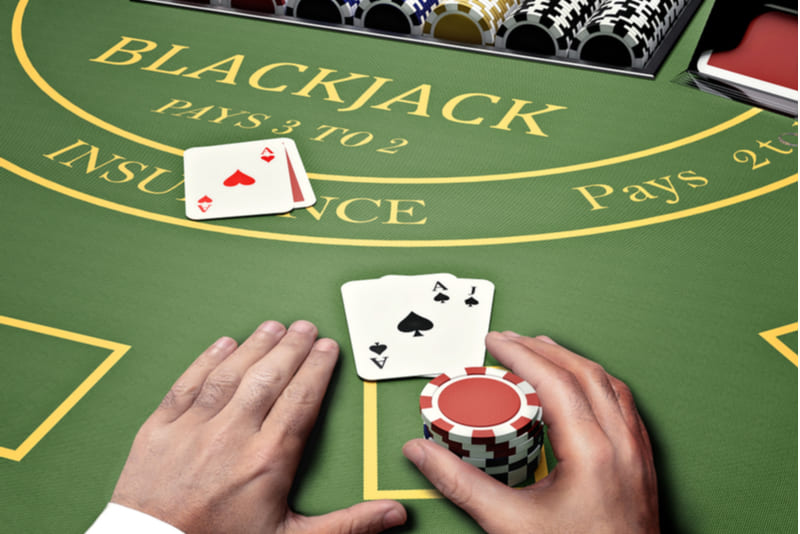


*Nota*: O conteúdo deste notebook é derivado dos capítulos 5 e 6 de Sutton e Barto, "Reinforcement Learning, an Introduction".

O Blackjack é um jogo de cartas popular em cassinos.
O objetivo do jogo é obter mais pontos do que o adversário, sem exceder o limite de 21 pontos.

Em uma versão simplificada, o jogador joga contra a banca.
Inicialmente é dada uma carta para o jogodor e uma para a banca (na verdade duas, mas a segunda é dada de "face para baixo").

A pontuação das cartas segue o valor de face dos números.
As cartas de "face" (Valete, Rainha e Rei) valem 10 pontos.
Um ás vale 1 ou 10 pontos, de acordo com a vontade do jogador.

O jogador tem duas jogadas possíveis, "hit" e "stick".
Em "Hit" o jogador recebe uma nova carta e continua a jogar.
Em "Stick" o jogador encerra a sua jogada.

Em seguida a banca faz a mesma coisa (antes abrindo sua carta oculta).
Tradicionalmente a banca deve seguir uma estratégia fixa, que dita que ela deve escolher "hit" em todas as mãos com valor menor que 17 e "stick" em mãos com valor 17 ou superior.

O jogador perde automaticamente se exceder o valor 21.
Caso contrário, se a banca exceder 21 o jogador vence.
Se ninguém exceder 21, ganha quem tiver a mão com maior valor.
Se ambas as mãos possuem o mesmo valor, o jogo termina empatado.

### Os ambientes Gym/Gymnasium

A biblioteca Gym é uma biblioteca open source para aprendizado de máquina criada pela OpenAI.

Ela unifica a formalização de modelos decisórios de Markov e contém diversos ambientes relevantes para testes de algoritmos de Aprendizagem por Reforço.

Atualmente ela está sendo substituída pela biblioteca Gymnasium.
Nem toda distribuição inclui a gymnasium.
Execute a célula abaixo se seu ambiente não tem a biblioteca instalada (ou instale de acordo com seu ambiente).

In [5]:
# !pip3 install gymnasium


In [6]:
import gymnasium as gym


As bibliotecas gym/gymnasium introduzem o conceito de *ambientes* (Environment).

Um ambiente possui um espaço de *estados* e um espaço de *ações*.
O ambiente evolui em etapas discretas, recebendo uma ação do ator e retornando um novo estado e a correspondente recompensa.

Há um ambiente preparado para o jogo de BlackJack.
Sua documentação está em [https://gymnasium.farama.org/environments/toy_text/blackjack/](https://gymnasium.farama.org/environments/toy_text/blackjack/)

Vamos criar esse ambiente:

In [7]:
blackjack_01 = gym.make("Blackjack-v1", sab=True, render_mode="rgb_array")


Podemos verificar o espaço de ações:

In [8]:
blackjack_01.action_space


Discrete(2)

O resultado ```Discrete(2)```  mostra que o espaço de ações é uma variável de uma dimensão discreta com 2 valores possíveis.
O valor 0 corresponde à ação "Stick", o valor 1 corresponde à ação "Hit".


Podemos também verificar o espaço de estado:

In [9]:
blackjack_01.observation_space


Tuple(Discrete(32), Discrete(11), Discrete(2))

Isso é menos trivial.
O espaço contém 3 componentes, uma variável discreta com 32 valores possíveis, uma variável discreta com 11 valores possíveis e uma variável com 2 valores possíveis.

Não parece possível representar o estado completo de um jogo de cartas nestas 3 componentes.

De fato não é, mas em processos decisórios de Markov só é necessário considerar os aspectos do estado relevantes para as decisões.

Ignorando-se técnicas de contagem de cartas (que não são relevantes no modelo simplificado), apenas o *valor* das mãos e a disponibilidade de um Ás são relevantes.

Ademais, a banca só joga depois que o jogador encerrou suas jogadas.
Assim, é relevante apenas o valor da única carta visível da banca.

Assim, as três componentes do estado são:


1.   Valor total das cartas do Jogador
2.   Valor da única carta visível da banca
3.   Verdadeiro se há um ás valorizado como 10, falso caso contrário.

Note que o Ás é sempre valorizado de forma a maximizar o valor da mão do jogador, desde que isso não exceda 21.

Por exemplo, se a mão do jogador contém as cartas 3, 5, Ás, e a banca mostra um Rei, o estado é (18, 10, Verdadeiro).


Os métodos relevantes do ambiente são ```reset()```  e ```step(acao)```.

O método ```reset()``` inicia um novo episódio no ambiente.
Ele retorna uma tupla com o estado inicial do ambiente e um campo com informações (que pode ser ignorado aqui).

Por exemplo:

In [10]:
estado, _ = blackjack_01.reset()
print(estado)


(19, 10, 1)


Talvez você tenha recebido um valor da mão do jogador maior que 10.
Como isso pode acontecer?

Nota-se que enquanto o valor da mão for menor que 12, não há razão para usar a ação "stick".
Sabendo disso, o ambiente automaticamente dá mais cartas para o jogador até que a mão deste tenha um valor de 12 ou mais.

É possível mostrar uma representação gráfica do ambiente com o método ```render()```

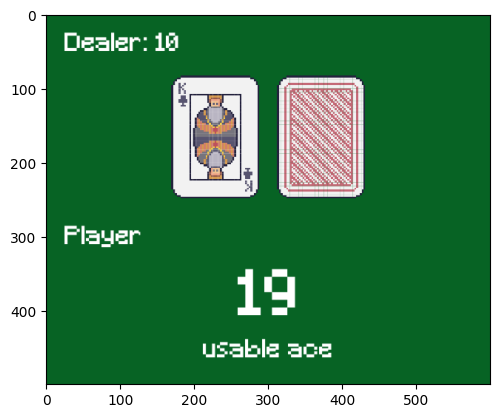

In [11]:
plt.imshow(blackjack_01.render())


O método ```step(acao)``` simula o efeito da ação no ambiente.
Ele retorna 5 componentes, o novo estado do ambiente, a recompensa dada naquele passo, uma variável booleana que é verdadeira se o jogo terminou, uma variável booleana que indica se o episódio foi truncado (pode ser ignorada aqui) e uma variável com informações (que pode ser ignorada aqui).

A recompensa é 0 se o jogo ainda não terminou.
Se o jogo terminou com vitória do jogador, a recompensa é 1.
Se o jogo terminou com vitória da banca, a recompensa é -1.
Se o jogo terminou em empate, a recompensa é 0.

Vamos simular o efeito de uma ação "hit":

(16, 10, 0)
0.0
False


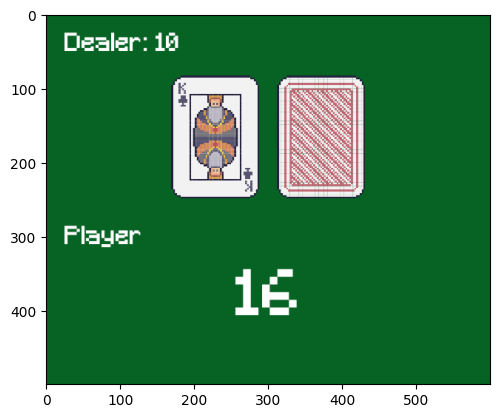

In [12]:
novo_estado, recompensa, terminou, _, _ = blackjack_01.step(1)
print(novo_estado)
print(recompensa)
print(terminou)
plt.imshow(blackjack_01.render())


Podemos criar uma classe para um jogador nos moldes do que foi feito no exercício do Jogo-da-velha.

O método ```escolhe_jogada(estado_jogo)``` escolhe a próxima ação a ser tomada.

O método ```confirma_acao(estado_jogo_antes, acao, estado_jogo_depois)``` serve para Aprendizagem. Ele informa ao jogador qual a ação que foi efetivamente tomada.

O método ```notifica_fim(estado_jogo_final, resultado)``` também serve para Aprendizagem. Ele informa ao jogador que chegou-se a um estado terminal.

O método ```novo_episodio()``` informa o jogador que um novo episódio iniciou-se.

A classe ```jogadorStickEm20``` implementa um jogador com estratégia fixa.
A estratégia é sempre escolher "hit" para mãos com valores menores que 20 e "stick" para mãos com valores maiores ou iguais a 20.


In [13]:
class jogadorStickEm20():
  def __init__(self):
    pass

  def escolhe_jogada(self, estado_jogo):
    if estado_jogo[0]>=20:
      return 0
    else:
      return 1

  def confirma_acao(self, estado_jogo_antes, acao, estado_jogo_depois):
    pass

  def notifica_fim(self, estado_jogo_final, resultado):
    pass

  def novo_episodio(self):
    pass


A função ```simula_jogador_gym``` executa um episódio de simulação do Blackjack:

In [14]:
def simula_jogador_gym(env, jogador, func = None):
  jogador.novo_episodio()
  estado_depois, _ = env.reset()
  if func:
    func([estado_depois, 0])
  terminou = False
  while not terminou:
      estado_antes = estado_depois
      acao = jogador.escolhe_jogada(estado_antes)
      estado_depois, res, terminou, _, _ = env.step(acao)
      jogador.confirma_acao(estado_antes, acao, estado_depois)
      if func:
        func([estado_depois, res])
  jogador.notifica_fim(estado_depois, res)
  return res


In [15]:
resultados_jogador_stick_em_20 = []
blackjack_teste = gym.make("Blackjack-v1", sab=True)
jogador_stick_20 = jogadorStickEm20()
simula_jogador_gym(blackjack_teste, jogador_stick_20, lambda res: resultados_jogador_stick_em_20.append(res))
for estado, recompensa in resultados_jogador_stick_em_20:
  print("Estado: " + str(estado))
  print("Recompensa: " + str(recompensa))


Estado: (17, 5, 0)
Recompensa: 0
Estado: (25, 5, 0)
Recompensa: -1.0


#1 Avaliação de Política pelo método de Monte Carlo

A técnica vista na aula passada para se avaliar a política parece um pouco trabalhosa neste exercício.
Ao contrário do modelo passado, este sistema é *estocástico*.
Assim, para avaliar-se o resultado de uma política com o método da aula passada é necessário considerar todas as transições possíveis com as correspondentes probabilidades.

O Método de Monte Carlo dispensa um modelo estocástico e estima valores para estados usando apenas experiências em episódios.

A ideia é coletar uma grande quantidade de episódios seguindo uma determinada política.

A ideia é calcular para cada episódio o retorno total em cada um dos estados visitados *na primeira vez* em que o estado é visitado no episódio (há uma variante que desconsidera esta restrição, mas ela não será abordada aqui).

Em seguida calcula-se a média destes valores por estado para todos os episódios.

Eis uma descrição do algoritmo retirada de "Reinforcement Learning - An Introduction":

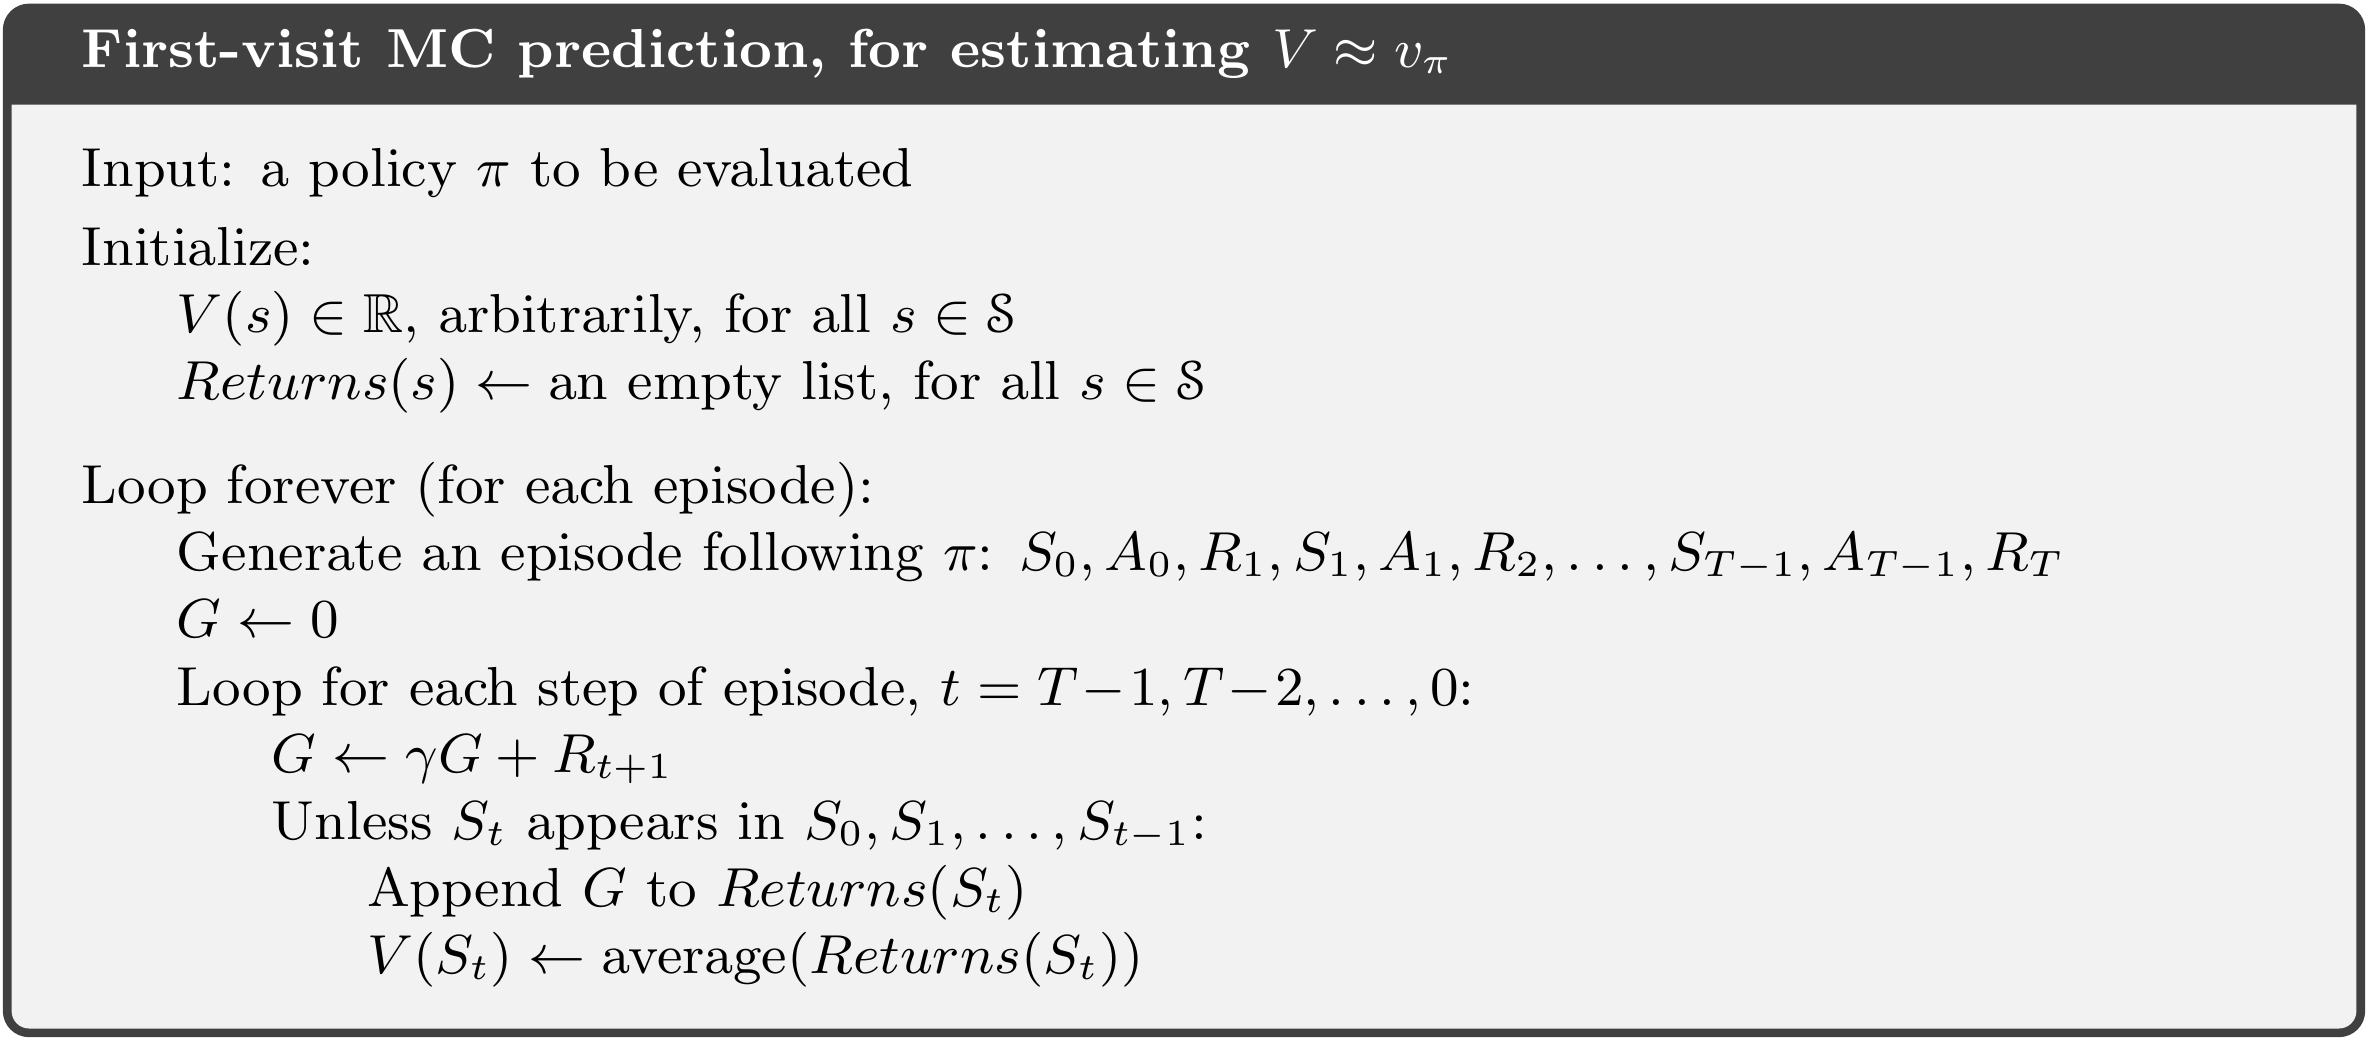

(Repr. de Sutton e Barto 2002 (cap. 5))

Note que para o caso específico do BlackJack, em cada episódio um estado é visitado *apenas uma vez*.

Note também que não é necessário armazenar todos os retornos para cada episódio.

De fato, suponha $n_{i}$ a quantidade de vezes que o estado $e$ foi visitado até o $i$-gésimo episódio.
Suponha $v_{i}(e)$ a média de retornos do estado $e$ até o $i$-gésimo episódio.

Se o estado $e$ foi visitado no episódio $t+1$ e o seu retorno na primeira visita foi $G_e$, então:

\begin{align}
n_{i+1}(e) &= n_{i}(e) + 1 \\
v_{i+1}(e) &= v_{i}(e) + \frac{G_e - v_{i}(e)}{n_{i+1}(e)}
\end{align}

Caso contrário, naturalmente,

\begin{align}
n_{i+1}(e) &= n_{i}(e)  \\
v_{i+1}(e) &= v_{i}(e)
\end{align}


### Exercício:
Complete a implementação da função ```mc_avalia_v_gym```.

O parâmetro ```jogador``` é um objeto como o da classe ```jogadorStickEm20``` vista acima.
O parâmetro ```env``` é um ambiente gym com um jogo de blackjack.
O parâmetro ```n``` é a quantidade total de episódios a ser avaliada.
O parâmetro ```gamma```  é o valor da constante $\gamma$ de desconto para cálculo do retorno total.
O parâmetro ```funcao_progresso``` é opcional e representa uma função a ser invocada a cada episódio para relatar o progresso da avaliação.


Em cada episódio esta função deve preencher a sequência ```estados``` com cada estado visitado durante o episódio, na ordem em que eles são encontrados (É desnecessário incluir o estado terminal).

Observe que esta função possui dois dicionários, o ```v_valores``` e o ```v_cont_visitas```.
```v_cont_visitas``` é um dicionário que associa a cada estado a quantidade total de vezes que ele foi visitado durante um episódio.
Ao final de cada episódio estes dois dicionários devem ser atualizados.
Atenção para casos em que o dicionário ainda não contém a chave correspondente ao episódio!

Note que o retorno total deve ser calculado "de trás para frente".
Note também que no caso específico do Blackjack, a única transição com recompensa é a final (de modo que nesta função as recompensas intermediárias são ignoradas).

In [16]:
def mc_avalia_v_gym(jogador, env, n, gamma, funcao_progresso=None):
  v_valores = {}      # Estimativa de valor para cada estado
  v_cont_visitas = {} # Total de vezes que o estado foi visitado
  for i in range(n):
    estado_depois, _ = env.reset()
    jogador.novo_episodio()
    estados = []      # Sequência de estados do episódio atual
    terminou = False
    while not terminou:
      estado_antes = estado_depois
      acao = jogador.escolhe_jogada(estado_antes)
      estado_depois, res, terminou, _, _ = env.step(acao)
      jogador.confirma_acao(estado_antes, acao, estado_depois)
      # Complete com seu código: atualize estados
      estados.append(estado_antes)
      
    jogador.notifica_fim(estado_depois, res)

    # Complete com seu código: Atualize v_cont_visitas e v_valores
    #   Neste ponto a variável res deve conter a recompensa final
    #   e a variável estados deve conter a sequência em ordem direta
    #   de todos os estados visitados.
    G = res  
    estados_visitados = set() 

    for estado in estados:
        if estado not in estados_visitados:
            estados_visitados.add(estado)
            
            if estado not in v_cont_visitas:
                v_cont_visitas[estado] = 0
                v_valores[estado] = 0.0
            
            v_cont_visitas[estado] += 1
            
            alpha = 1.0 / v_cont_visitas[estado]
            v_valores[estado] += alpha * (G - v_valores[estado])

    if funcao_progresso:
      funcao_progresso(i)
  return v_valores


Teste seu código avaliando a política de "stick" abaixo de 20:
O valor do estado em que o jogador tem uma mão valendo 13 com um ás e a banca mostra um 2 deve estar entre -0,2 e -0,3.

In [17]:
np.random.seed(0)
experimentos = 1000000
env = gym.make("Blackjack-v1", sab=True)
progresso = widgets.IntProgress(min=0, max=experimentos)
display(progresso)
def atualiza_progresso(i):
  if i%100==0:
    progresso.value = i
valores = mc_avalia_v_gym(jogadorStickEm20(), env, experimentos, 1.0, atualiza_progresso)
print(valores[(13,2,True)])


IntProgress(value=0, max=1000000)

-0.26579520697167763


Pode-se plotar os valores para cada política, com e sem Ás.
Note que há um "degrau" quando a mão do jogador vale 20.
Você sabe explicar isso?

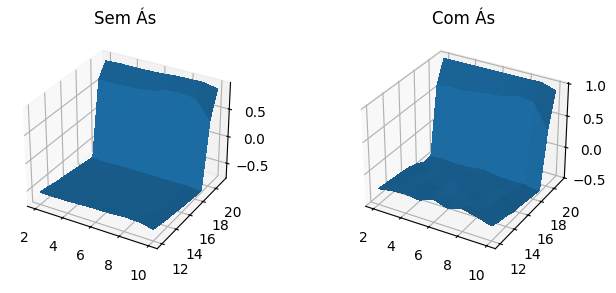

In [18]:
fig = plt.figure(figsize=(8, 3))
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')

# fake data
_x = np.arange(2,11)
_y = np.arange(12,22)
xx, yy = np.meshgrid(_x, _y)

top1 = np.array([[valores[(j, b, False)] for b in _x] for j in _y])
top2 = np.array([[valores[(j, b, True)] for b in _x] for j in _y])

ax1.plot_surface(xx, yy, top1,
                       linewidth=0, antialiased=False)

ax1.set_title("Sem Ás")

ax2.plot_surface(xx, yy, top2,
                       linewidth=0, antialiased=False)

ax2.set_title("Com Ás")

plt.show()


#2. Aprendizagem de Monte Carlo (de novo!)

Na primeira aula tivemos uma prévia da aprendizagem de Monte Carlo.
O algoritmo consistia em explorar o ambiente com uma política "$\epsilon$-gulosa". Nesta política, com probabilidade $\epsilon$, o ator adota uma ação puramente aleatória. Com probabilidade $1-\epsilon$, o ator escolhe o que estima ser a melhor ação possível.

O problema do BlackJack, no entanto, tem uma propriedade incomum que nos permite fazer uma versão mais simples do Algoritmo.
A propriedade é a de "Inícios Exploradores" (*Exploring Starts*).
Processos com esta propriedade são processos nos quais *todas* as combinações possíveis de estados e ações são possíveis *na configuração de partida*. Note que embora seja o caso do BlackJack, nem todo processo decisório de Markov tem essa propriedade.

Quando o processo tem esta propriedade, é possível fazer um algoritmo de exploração que segue *sempre* a melhor estratégia conhecida, *exceto* no primeiro movimento.

O algoritmo neste caso tenta estimar o valor da função $Q(S, A)$, que estima o retorno esperado ao se tomar a ação $A$ a partir do estado $S$.
Veja que, ao contrário da função de valor do estado, a função $Q$ depende de um estado e uma ação.

O algoritmo consiste em se executar um episódio segundo uma política "gulosa", que seleciona no primeiro estado $S_0$ uma ação compeltamente aleatória $A_0$ e nos estados subsequentes $S_t$ a ação $A_t$ que *maximiza* $Q(S_t, A_t)$.

Ao final de cada episódio é calculado o retorno esperado "de trás para frente" com a relação:

\begin{equation}
G_t = \gamma G_{t+1} + R_{t+1}
\end{equation}

Do mesmo modo que na exploração de Monte Carlo vista acima, usa-se a média dos valore $G_t$ no *primeiro* momento em que um dado par $(S_t, A_t)$ para se estimar o valor $Q(S_t, A_t)$.

Eis uma descrição do algoritmo reproduzida de "Reinforcement Learning - An Introduction (2nd ed.)":

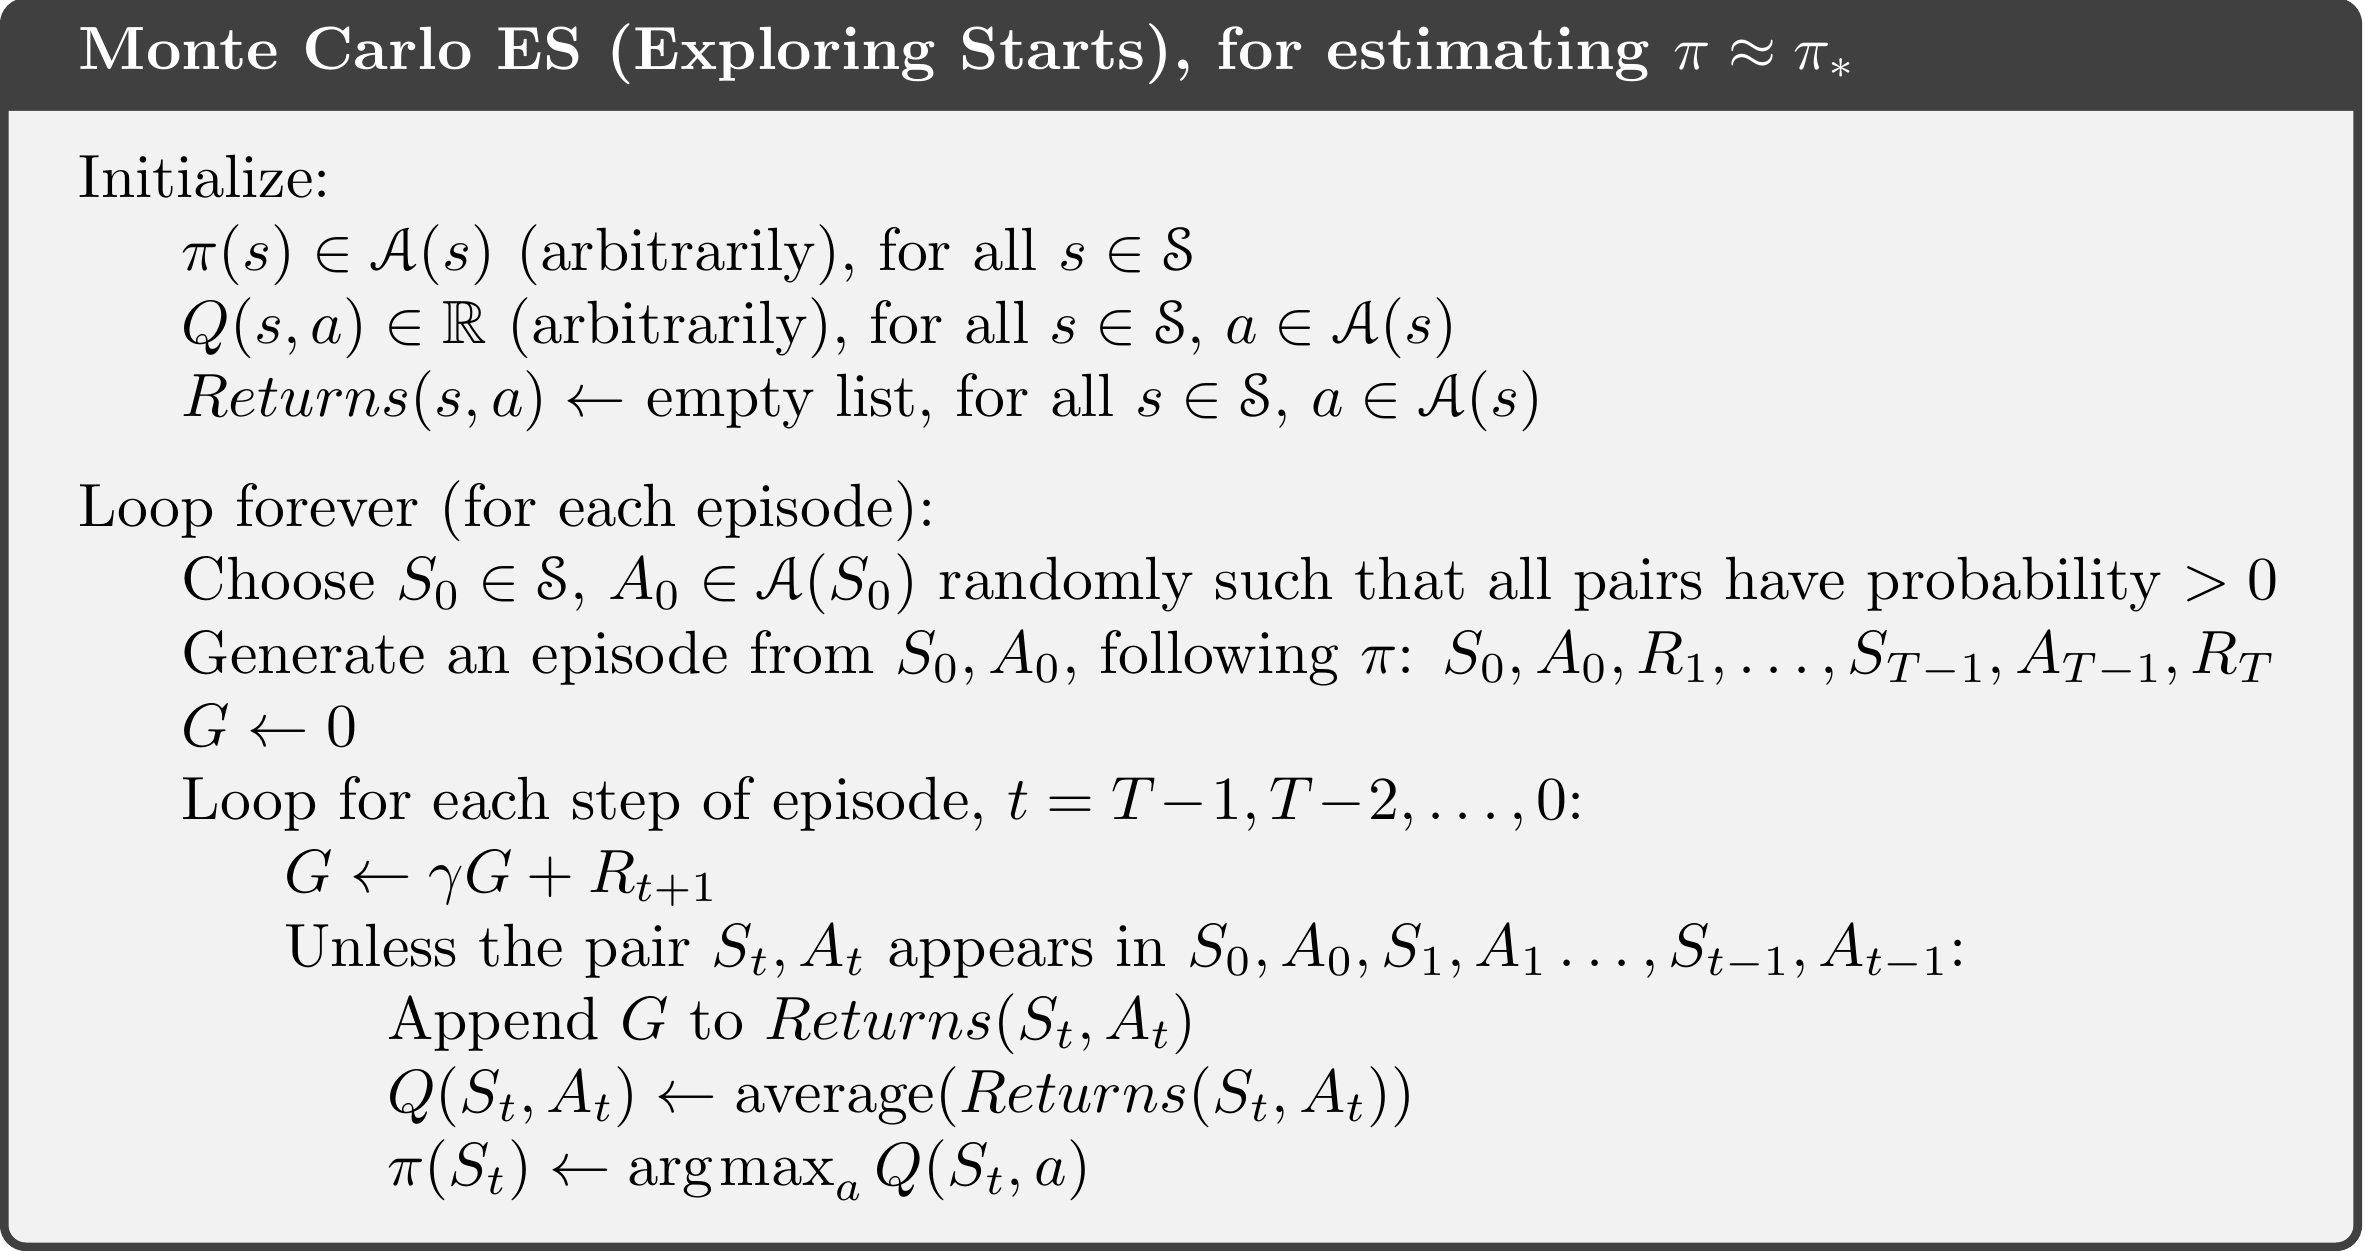

(repr. de  Sutton e Barto 2002 cap. 5)

Como se vê, vamos passar a usar tabelas de valores de $Q(S,A)$.

Para o BlackJack, estas tabelas serão dicionários cujas chaves são estados e os valores são vetores com duas componentes.
O primeiro componente é o valor de $Q$ para a ação "Stick" e o segundo componente é o valor de $Q$ para a ação "Hit".

Um ator "$Q$-Guloso" é um ator que segue a política que escolhe sempre a ação com maior valor de Q.

A classe ```jogadorGreedyQ``` implementa um jogador com este comportamento.
No seu construtor é passada uma tabela com a estimativa de $Q$.

In [19]:
class jogadorGreedyQ():
  def __init__(self, q):
    self._q = q

  def escolhe_jogada(self, estado_jogo):
    if estado_jogo in self._q:
      return np.argmax(self._q[estado_jogo])
    else:
      return np.random.choice([0,1])

  def confirma_acao(self, estado_jogo_antes, acao, estado_jogo_depois):
    pass

  def notifica_fim(self, estado_jogo_final, resultado):
    pass

  def novo_episodio(self):
    pass


É possível criar uma tabela $Q$ que faz o jogador se comportar com a estratégia de "Stick em 20 ou maior":

In [20]:
tabela_q_stick_20 = {(jog, banca, as_util): [-0.1, 0.1] if jog < 20 else [0.1, -0.1]\
                     for jog in range(2, 33)\
                     for banca in range(1, 11)\
                     for as_util in [False, True]}


Observe que um jogador "$Q$-guloso" que segue a  tabela ```tabela_q_stick_20``` se comporta como o jogador da classe ```jogadorStickEm20```:


In [21]:
estados = [(13,2,True), (12, 10, False), (20, 7, False), (21, 5, True) ]
nome_jogada = ["Stick", "Hit"]
jogador1 = jogadorStickEm20()
jogador2 = jogadorGreedyQ(tabela_q_stick_20)
for e in estados:
  print("Estado: " + str(estado))
  print("Valor da tabela tabela_q_stick_20 para este estado: " + str(tabela_q_stick_20[e]))
  print("Ação do jogadorStickEm20: " + nome_jogada[jogador1.escolhe_jogada(e)])
  print("Ação do jogadorGreedyQ com a tabela tabela_q_stick_20: " + nome_jogada[jogador1.escolhe_jogada(e)])


Estado: (25, 5, 0)
Valor da tabela tabela_q_stick_20 para este estado: [-0.1, 0.1]
Ação do jogadorStickEm20: Hit
Ação do jogadorGreedyQ com a tabela tabela_q_stick_20: Hit
Estado: (25, 5, 0)
Valor da tabela tabela_q_stick_20 para este estado: [-0.1, 0.1]
Ação do jogadorStickEm20: Hit
Ação do jogadorGreedyQ com a tabela tabela_q_stick_20: Hit
Estado: (25, 5, 0)
Valor da tabela tabela_q_stick_20 para este estado: [0.1, -0.1]
Ação do jogadorStickEm20: Stick
Ação do jogadorGreedyQ com a tabela tabela_q_stick_20: Stick
Estado: (25, 5, 0)
Valor da tabela tabela_q_stick_20 para este estado: [0.1, -0.1]
Ação do jogadorStickEm20: Stick
Ação do jogadorGreedyQ com a tabela tabela_q_stick_20: Stick


Observe o conteúdo da tabela. Você consegue entender por que ela produz este comportamento?

### Exercício:

a) Complete a implementação da classe ```jogadorAprendizadoMC_ES```.

Esta classe implementa um jogador que *atualiza* sua tabela de valores de $Q(S,A)$.
Assim como no exemplo acima, a função $Q$ é representada por um dicionário no qual as chaves são os possíveis estados, e os valores são vetores com tantos coeficientes quantas ações possíveis em cada estado (no caso do BlackJack, são dois coeficientes, o primeiro para "Stick", o segundo para "Hit").

Para tanto ela armazena sequências de estados e ações para cada epiśido, nos atributos ```_estados``` e ```_acoes``` respectivamente.
Estas sequências são zeradas no método ```novo_episodio()```.
Além disso ela armazena a *quantidade* total que cada par $(S, A)$ é encontrado no atributo ```_q_count``` para cálculo incremental das estimativas de valores de $Q$.

O método ```escolhe_jogada``` age como um jogador "$Q$-guloso" seguindo para o estado $S$ a ação $A$ com máximo valor estimado de Q.
A exceção está no *primeiro* movimento, em que o jogador escolhe uma ação aleatória.

Você deve completar a implementação de ```confirma_acao(estado_jogo_antes, acao, estado_jogo_depois)``` e ```notifica_fim(estado_jogo_final, resultado)```.

Em ```confirma_acao(estado_jogo_antes, acao, estado_jogo_depois)``` você deve atualizar as sequências de ações e estados em ```_estados``` e ```_acoes```. Pergunta: Se você está interessado no par $S, A$ na avaliação de $Q(S, A)$, você deve usar o valor do estado em ```estado_jogo_antes``` ou ```estado_jogo_depois```?

A função ```notifica_fim(estado_jogo_final, resultado)``` é chamada ao final do episóndo.
Nela você deve percorrer de trás para frente os pares de estado-ação e atualizar os valores de ```_q_count``` e ```_q```.

In [22]:
class jogadorAprendizadoMC_ES():
  def __init__(self, q, gamma):
    # Tabela de valores Q
    self._q = q
    # Conta quantas vezes cada valor Q(s, a) foi visto
    self._q_count = {e :[0,0] for e in self._q}
    self._gamma = gamma
    self.novo_episodio()

  # Chamada ao início de um novo episódio
  def novo_episodio(self):
    self._primeira_jogada=True
    # Lista de estados em cada episódio
    self._estados = []
    # Lista de ações tomadas em cada estado
    self._acoes = []


  def escolhe_jogada(self, estado_jogo):
    if self._primeira_jogada: # Primeira jogada sempre aleatória
      self._primeira_jogada = False
      acao = np.random.choice([0,1])
      return acao
    if estado_jogo in self._q:  # Jogada q-greedy
      return np.argmax(self._q[estado_jogo])
    else:
      return np.random.choice([0,1])

  def confirma_acao(self, estado_jogo_antes, acao, estado_jogo_depois):
    # Complete com seu código:
    #   Adicione o estado do jogo antes da ação e a ação tomada
    #   às listas self._estados e self._acoes
    self._estados.append(estado_jogo_antes)
    self._acoes.append(acao)


  def notifica_fim(self, estado_jogo_final, resultado):
    # Complete com seu código:
    #   Calcule de trás para frente os retornos e
    #   atualize as tabelas self._q_count e self._q
    G = resultado 
    for i in range(len(self._estados) - 1, -1, -1):
        estado = self._estados[i]
        acao = self._acoes[i]
        
        self._q_count[estado][acao] += 1
        
        alpha = 1.0 / self._q_count[estado][acao]
        self._q[estado][acao] += alpha * (G - self._q[estado][acao])
        
        G = self._gamma * G


Verifique o seu trabalho:
Este código roda o algoritmo com 2500000 episódios e coloca os resultaods na variável ```tabela_mc_es```.
Observe que a estratégia de partida é exatamente a da tabela ```tabela_q_stick_20```.

In [23]:
tabela_mc_es = {e : list(tabela_q_stick_20[e]) for e in tabela_q_stick_20}
jogador = jogadorAprendizadoMC_ES(tabela_mc_es, 1.0)
experimentos = 2500000
progresso = widgets.IntProgress(min=0, max=experimentos)
blackjack = gym.make("Blackjack-v1", sab=True)
display(progresso)
for i in range(experimentos):
  simula_jogador_gym(blackjack, jogador)
  if i%200==0:
    progresso.value = i


IntProgress(value=0, max=2500000)

Verifique a estratégia resultante:

O livro "Reinforcement Learning, and Introduction" mostra o que deve ser a estratégia ideal. Seu resultado deve ser pŕoximo.


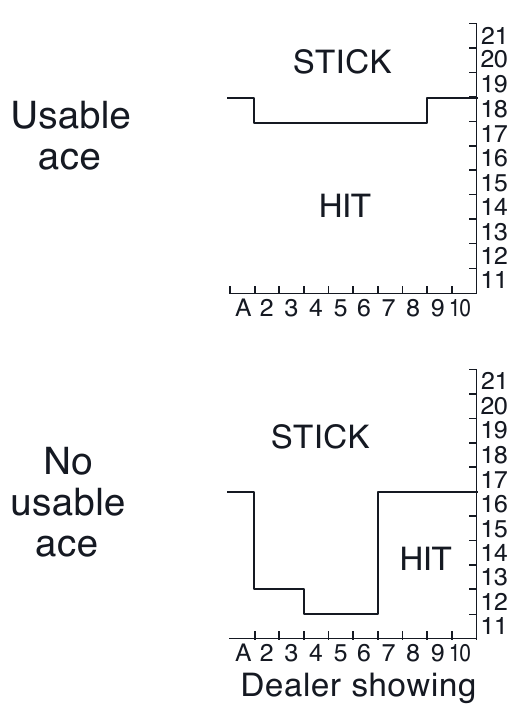

Text(0.5, 1.0, 'Com ás')

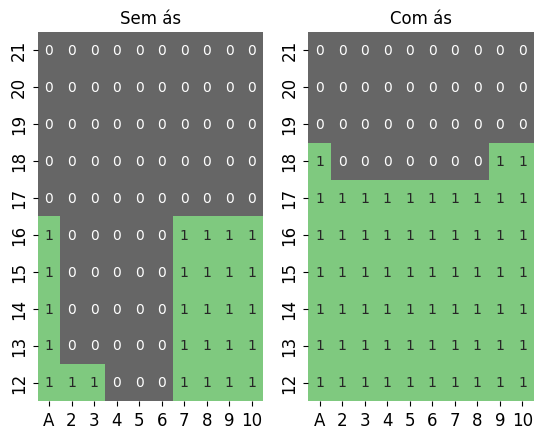

In [25]:
import seaborn as sns
banca, jogador = np.meshgrid(
    np.arange(1, 11),
    np.arange(21, 11, -1)
)

politicas_sem_as = np.apply_along_axis(lambda obs: np.argmax(tabela_mc_es[(obs[1], obs[0], False)]), axis=2, arr=np.dstack([banca, jogador]))
politicas_com_as = np.apply_along_axis(lambda obs: np.argmax(tabela_mc_es[(obs[1], obs[0], True)]), axis=2, arr=np.dstack([banca, jogador]))

fig, (ax1,ax2) = plt.subplots(1,2)
sns.heatmap(politicas_sem_as, linewidth=0, annot=True, cmap="Accent_r", cbar=False, ax=ax1)
ax1.set_yticklabels(np.arange(21, 11, -1), fontsize=12)
ax1.set_xticklabels(["A"] + list(range(2, 11)), fontsize=12)
ax1.set_title("Sem ás")
sns.heatmap(politicas_com_as, linewidth=0, annot=True, cmap="Accent_r", cbar=False, ax=ax2)
ax2.set_yticklabels(np.arange(21, 11, -1), fontsize=12)
ax2.set_xticklabels(["A"] + list(range(2, 11)), fontsize=12)
ax2.set_title("Com ás")


b) Por hipótese você treinou um jogador que deve ter um comportamento muito próximo do ideal.
Um objeto da classe ```jogadorGreedyQ``` construída com a tabela ```tabela_mc_es``` treinada acima deve jogar Blackjack tão bem quanto possível.

Verifique o retorno médio de 10000 episódios usando a função ```simula_jogador_gym``` declarada acima.

O que o seu resultado diz sobre a natureza do Blackjack?

In [28]:

jogador_greedy = jogadorGreedyQ(tabela_mc_es)

retornos = []
for i in range(10000):
    retorno = simula_jogador_gym(blackjack, jogador_greedy)
    retornos.append(retorno)
retorno_medio = np.mean(retornos)
print(f"Retorno médio após 10000 episódios: {retorno_medio}")


Retorno médio após 10000 episódios: -0.0456


# 3. O "Problema do Penhasco" (*Cliffwalk*) e SARSA *versus* Q-Learning

Trata-se de um *GridWorld* com 4 linhas e 12 Colunas.
A posição de partida é sempre a da 4a linha, 1a coluna.
A configuração de término é na 4a linha, 12a coluna.
Os movimentos que levariam o agente para "fora do mundo" mantém-o na mesma posição.

As casas da última linha, da segunda até a penúltima são especiais. Elas correspondem ao "penhasco". Todos os movimentos que levariam o agente até uma dessas casas transportam-no para a casa de partida com uma recompensa de -100.
Todos os outros movimentos têm uma recompensa de -1.

A biblioteca ```gym``` possui uma implementação do problema do penhasco.

In [30]:
clifwalk_01=gym.make("CliffWalking-v1", render_mode="rgb_array")


O espaço de ações para este mundo é de 4 ações discretas:

In [31]:
clifwalk_01.action_space


Discrete(4)

As ações correspondem a:

0. "Para cima"
1. "Para a direita"
2. "Para baixo"
3. "Para a esquerda"

O espaço de observações é uma variável discreta com 48 valores possíveis:

In [32]:
clifwalk_01.observation_space


Discrete(48)

Se $i$ é a linha (baseada em 0) e $j$ é a coluna (também baseada em 0), então o número da posição é dado por $j+12i$.

Deste modo, a posição inicial, com $i=3$ e $j=0$ é 36:

In [33]:
clifwalk_01.reset()


(36, {'prob': 1})

Podemos simular este mundo com um agente dando dois passos para cima, dois para a direita e dois para baixo.

Note que o último passo coloca o agente no "penhasco" e leva-o novamente para o início.

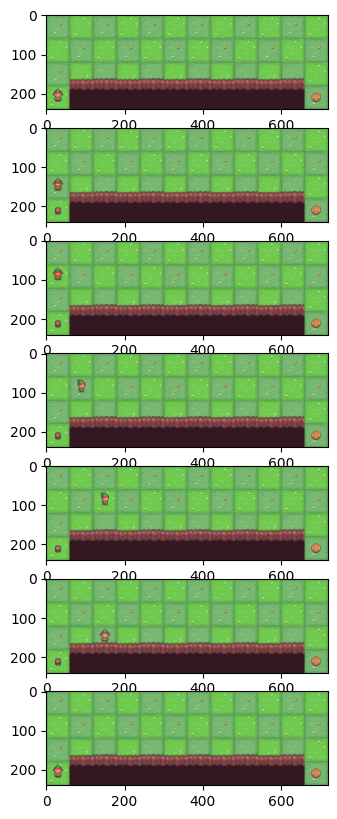

In [34]:
clifwalk_01.reset()
fig, ax = plt.subplots(7, figsize=(10,10))
ax[0].imshow(clifwalk_01.render())
clifwalk_01.step(0)
ax[1].imshow(clifwalk_01.render())
clifwalk_01.step(0)
ax[2].imshow(clifwalk_01.render())
clifwalk_01.step(1)
ax[3].imshow(clifwalk_01.render())
clifwalk_01.step(1)
ax[4].imshow(clifwalk_01.render())
clifwalk_01.step(2)
ax[5].imshow(clifwalk_01.render())
clifwalk_01.step(2)
ax[6].imshow(clifwalk_01.render())


## 3.1 SARSA

Os métodos de Monte Carlo para estimativa da política ótima usam uma política $\pi$ "soft" (Sejam "$\epsilon$-gulosas" como no exercício do jogo-da-velha ou políticas que exploram diferentes ações iniciais, como no caso do Monte Carlo Exploring Starts) para explorar o espaço de ações e estimar os valores de $Q_\pi(S,A)$.

Em seguida eles criam uma nova política, baseada nas novas estimativas de $Q_\pi(S,A)$ e repetem o processo.

Nos métodos de Monte Carlo, a atualização das estimativas dos valores de $Q$ ocorre *somente após o término de cada episódio*.

Em contrapartida, os métodos de diferenças temporais atualizam as estimativas de $Q$ *a cada passo*.

Um exemplo de método de diferença temporal é o SARSA.

Vamos recapitular as equações de recorrência para valores de estado:

\begin{equation}
v_{\pi}(S) = \sum_A \pi(A) \sum_{R, S'} p(R, S' | S, A) \left(R + \gamma v(S')\right)
\end{equation}

Esta é uma equação que define $v_\pi(S)$ em função de todos os valores dos possíveis estados sucessores $S'$.

Considerando-se a definição de valor do par ação-estado:

\begin{align}
Q_{\pi}(S, A) &= \sum_{R, S'} p(R, S' | S, A) \left(R + \gamma v(S')\right)\\
v_{\pi}(S) &= \sum_A \pi(A) Q(S,A)
\end{align}

Por esta definição, é possível definir uma equação recorrente o valor de um par estado-ação $Q(S, A)$ em função dos valores de todos os possíveis pares seguintes de estados-ações:

\begin{equation}
Q_{\pi}(S, A) = \sum_{R, S'} p(R, S' | S, A) \left(R + \gamma \sum_{A'} \pi(A') Q(S', A')\right)
\end{equation}


Esta equação motiva o algoritmo SARSA.

A ideia é aprimorar as estimativas para os valores de $Q(S,A)$ usando uma política "$\epsilon$-gulosa".

Considere que em uma etapa da exploração o agente estava no estado $S$, tomou a ação $A$, recebeu a recompensa $R$ e acabou no estado $S'$.
Na etapa seguinte, o agente tomou a ação $A'$.

Então, se $\tilde{q}(S,A)$ é uma estimativa para $Q(S,A)$, ela pode ser atualizada com:

\begin{equation}
\tilde{q}(S,A) \leftarrow \tilde{q}(S,A) + \alpha \left(R + \gamma \tilde{q}(S',A') - \tilde{q}(S,A) \right)
\end{equation}

onde $\alpha \leq 1$ é uma *taxa de aprendizado*.

Note que o SARSA usa *dois* pares de estado-ação para fazer esta atualização.
Ele atualiza a estimativa do par $(S, A)$ usando o valor da recompensa na transição de $S$ para $S'$ e a estimativa do par $(S', A')$.
Daí o seu nome, "SARSA".

Para o SARSA efetivamente estimar a política ótima, é necessário que a política "soft" gradativamente torne-se determinística.
Isso é feito rodando-se várias vezes o SARSA, a cada uma baixando-se o valor do parâmetro $\epsilon$.



### Exercício

Complete a classe ```atorSARSA``` que aprende uma política para o "CliffWalk".

Esta classe estima uma tabela de valores $Q(S, A)$ para uma política que resolve o "CliffWalk".

Como no exemplo anterior, tabelas de $Q(S,A)$ são implementadas como *dicionários de valores*.
Cada chave do dicionário é um estado possível do sistema.
Cada entrada é um vetor com tantas componentes quantas ações são possíveis (no caso do "CliffWalk", são 4 componentes).

O atributo ```_q``` contém a tabela de estimativas para os valores de $Q(S,A)$.
O atributo ```_gamma``` contém a constante de desconto $\gamma$.
O atributo ```_epsilon```  contém o valor da constante $\epsilon$ da política "$\epsilon$-gulosa".
O atributo ```_alpha``` é a taxa de aprendizagem $\alpha$.

O histórico recente de estados, ações e recompensas também é armazenado.
O atributo ```_prox_estado``` contém o estado mais recente visitado.
O atributo ```_acao_anterior``` contém a ação que levou ao estado mais recente.
O atributo ```_recompensa_anterior``` contém a recompensa obtida ao se chegar ao estado mais recente.
O atributo ```_estado_anterior```  contém o estado *anterior* ao estado mais recente.

O método ```novo_episodio(estado_inicial)``` notifica o agente que um novo episódio foi inciciado. Note que nesta etapa ainda não existem estados anteriores.

O método ```resultado_acao(acao, estado_resultante, recompensa)``` informa o resultado de uma ação.
A ação é passada no parâmetro ```acao```, o estado resultante é passado no parâmetro ```estado_resultante``` e a recompensa obtida é passada no parâmetro ```recompensa```.
Você deve completar a implementação desta função atualizando os valores em ```_q```.
Observe que esta função já atualiza os valores de ```_prox_estado```, ```_acao_anterior```, ```_recompensa_anterior``` e ```_estado_anterior```.

A função ```informa_termino()``` indica ao agente que o episódio terminou.
Esta função também deve ser completada.
Observe que, dada a forma "atrasada" de se atualizar valores para $(S,A)$ do SARSA, é necessário fazer uma última atualização neste momento.
Ao contrário dos métodos de Monte Carlo, não é necessário rever *todo* o histórico de ações neste momento. Apenas um valor deve ser atualizado!


In [35]:
class atorSARSA():
  def __init__(self, tabelaQ, epsilon, gamma, alpha):
    self._q = tabelaQ
    self._alpha = alpha
    self._epsilon = epsilon
    self._gamma = gamma

  def novo_episodio(self, estado_inicial):
    self._estado_anterior = None          # S
    self._acao_anterior = None            # A
    self._recompensa_anterior = None      # R
    self._prox_estado = estado_inicial    # S'

  # Agente epsilon-greedy
  def escolhe_movimento(self, estado):
    if np.random.rand()<self._epsilon:
      return np.random.choice([0,1,2,3])
    else:
      return np.argmax(self._q.get(estado, [0,0,0,0]))

  # Esta função atualiza o valor de q para o estado_anterior, acao_anterior!
  def resultado_acao(self, acao, estado_resultante, recompensa):
    if self._estado_anterior is not None:
      # Complete com seu código. Atualize aqui o valor de _q usando S, A, R S' e A'
      q_s_a = self._q.get(self._estado_anterior, [0,0,0,0])[self._acao_anterior]
      q_s_prime_a_prime = self._q.get(self._prox_estado, [0,0,0,0])[acao]

      if self._estado_anterior not in self._q:
          self._q[self._estado_anterior] = np.array([0.0, 0.0, 0.0, 0.0])

      self._q[self._estado_anterior][self._acao_anterior] += self._alpha * (
          self._recompensa_anterior + self._gamma * q_s_prime_a_prime - q_s_a
      )

    # Atualiza estado_anterior, _acao_anterior, _recompensa e _prox_estado (S,A,R,S')
    self._estado_anterior = self._prox_estado
    self._acao_anterior = acao
    self._prox_estado = estado_resultante
    self._recompensa_anterior = recompensa

  def informa_termino(self):
    # Complete com seu código. Atualize uma última vez o valor de Q. Note que aqui,
    #   S' é terminal, logo, Q(S',A') é sempre zero
    if self._estado_anterior is not None and self._acao_anterior is not None:
      q_s_a = self._q.get(self._estado_anterior, [0,0,0,0])[self._acao_anterior]
      
      if self._estado_anterior not in self._q:
          self._q[self._estado_anterior] = np.array([0.0, 0.0, 0.0, 0.0])
      
      self._q[self._estado_anterior][self._acao_anterior] += self._alpha * (
          self._recompensa_anterior + 0 - q_s_a
      )


Podemos testar este agente com a função ```simula_cliffwalk(env, ator, gamma)```.
Esta função simula um único episódio e retorna o retorno total recebido pelo agente durante o episódio.

In [36]:
def simula_clifwalk(env, ator, gamma):
  G = 0
  r = 1.0
  novo_estado, _ = env.reset()
  ator.novo_episodio(novo_estado)
  terminou = False
  while not terminou:
    estado_atual = novo_estado
    acao = ator.escolhe_movimento(estado_atual)
    novo_estado, recompensa, terminou, _, _ = env.step(acao)
    G += r*recompensa
    r *= gamma
    ator.resultado_acao(acao, novo_estado, recompensa)
  ator.informa_termino()
  return G


Os métodos de diferenças temporais precisam de valores iniciais para as estimativas de $Q$.

Vamos criar uma aleatória, com exceção do estado terminal, para o qual todos os valores de $Q$ são zero.

In [37]:
tabela_q = {i: np.random.rand(4) for i in range(47)}
tabela_q[47] = np.array([0.0, 0.0, 0.0, 0.0])


Podemos agora simular o SARSA para o problema do "CliffWalk" com 100 episódios.


IntProgress(value=0, max=1000)

C:\Users\mathe\AppData\Local\Temp\ipykernel_24028\1940648747.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


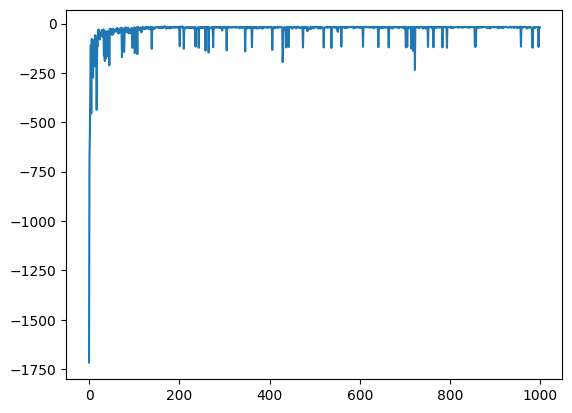

In [39]:
tabela_sarsa = {i: np.array(q) for i, q in tabela_q.items()}
experimentos = 1000
progresso = widgets.IntProgress(min=0, max=experimentos)
display(progresso)
clifwalk=gym.make("CliffWalking-v1")
retornos_sarsa = []
ator = atorSARSA(tabela_sarsa, 0.1, 1.0, 0.2)
for i in range(experimentos):
  ret = simula_clifwalk(clifwalk, ator, 1.0)
  retornos_sarsa.append(ret)
  if i%10==0:
    progresso.value = i
fig, ax = plt.subplots()
ax.plot(retornos_sarsa)
fig.show()


A estratégia final pode ser avaliada com um ator "guloso" que escolhe a melhor ação para cada estado:

In [40]:
class atorQGreedy():
  def __init__(self, tabelaQ):
    self._q = tabelaQ

  def novo_episodio(self, estado_inicial):
    self._estado_anterior = estado_inicial

  def escolhe_movimento(self, estado):
    return np.argmax(self._q.get(estado, [0,0,0,0]))

  def resultado_acao(self, acao, estado_resultante, recompensa):
    pass

  def informa_termino(self):
    pass


Podemos calcular o retorno total para esta estratégia:

In [41]:
print("Retorno SARSA: " + str(simula_clifwalk(clifwalk, atorQGreedy(tabela_sarsa), 1.0)))


Retorno SARSA: -17.0


Este é o resultado que você esperava? Por quê? Note que fizemos apenas uma batelada de simulações do SARSA, com $\epsilon = 0,1$.

Podemos também visualizar a trajetória do agente com uma animação:

In [44]:
def render_tabela(tabela_q):
  imagens = []
  clifwalk=gym.make("CliffWalking-v1", render_mode="rgb_array")
  ator = atorQGreedy(tabela_q)
  novo_estado, _ = clifwalk.reset()
  ator.novo_episodio(novo_estado)
  terminou = False
  imagens.append(clifwalk.render())
  while not terminou:
    estado_atual = novo_estado
    acao = ator.escolhe_movimento(estado_atual)
    novo_estado, recompensa, terminou, _, _ = clifwalk.step(acao)
    ator.resultado_acao(acao, novo_estado, recompensa)
    imagens.append(clifwalk.render())
  ator.informa_termino()
  return imagens


In [45]:
imagens = render_tabela(tabela_sarsa)
fig, ax = plt.subplots()
ims = []
for i in range(len(imagens)):
    if i == 0:
        ax.imshow(imagens[0])  # Imagem inicial
        ax.set_title("Estratégia SARSA")
    im = ax.imshow(imagens[i], animated=True)
    ims.append([im])
ani = animation.ArtistAnimation(fig, ims, interval=200, blit=True,
                                repeat_delay=1000)
plt.close()
HTML(ani.to_jshtml())


# 3.2 Q-Learning

O algoritmo Q-Learning, ao contrário do SARSA, tenta usar a política "soft" para estimar diretamente os valores de $Q$ da política ótima.

Suponha que o agente estava no estado $S$, tomou a ação $A$, acabou no estado $S'$ e recebeu a recompensa $R$.

Se $\tilde{q}(S,A)$ é a estimativa para $Q(S,A)$, esta pode ser atualizada com:

\begin{equation}
\tilde{q}(S,A) \leftarrow \tilde{q}(S,A) + \alpha \left(R + \gamma\, \underset{A'}{\mbox{max}\,} \tilde{q}(S',A') - \tilde{q}(S,A) \right)
\end{equation}

Note que ao contrário do SARSA, *não* é necessário saber qual a próxima ação $A'$ a ser tomada.
Escolhe-se o *máximo* de todos os valores de $\tilde{q}$ para o estado $S'$.


 ### Exercício
 Complete a classe ```atorQLearning``` que aprende via Q-Learning uma política para o "CliffWalk".

Assim como na classe anterior, esta classe estima uma tabela de valores $Q(S, A)$ para uma política que resolve o problema do "CliffWalk".
A representação da tabela $Q(S, A)$ é a mesma.

Novamente temos atributos repetidos:

O atributo ```_q``` contém a tabela de estimativas para os valores de $Q(S,A)$.
O atributo ```_gamma``` contém a constante de desconto $\gamma$.
O atributo ```_epsilon```  contém o valor da constante $\epsilon$ da política "$\epsilon$-gulosa".
O atributo ```_alpha``` é a taxa de aprendizagem $\alpha$.

O histórico é mais simples, temos apenas o atributo ```_estado_anterior```. Neste caso este atributo contém o estado mais recente já visto..

O método ```novo_episodio(estado_inicial)``` notifica o agente que um novo episódio foi inciciado.

O método ```resultado_acao(acao, estado_resultante, recompensa)``` informa o resultado de uma ação.
Novamente a ação é passada no parâmetro ```acao```, o estado resultante é passado no parâmetro ```estado_resultante``` e a recompensa obtida é passada no parâmetro ```recompensa```.
Você deve completar a implementação desta função atualizando os valores em ```_q```.
Observe que esta função já atualiza o valor de ```_estado_anterior```.

A função ```informa_termino()``` indica ao agente que o episódio terminou.
Como não há "atraso" nas estimativas do Q-Learning, nada é necessário aqui.


In [46]:
class atorQLearning():
  def __init__(self, tabelaQ, epsilon, gamma, alpha):
    self._q = tabelaQ
    self._alpha = alpha
    self._epsilon = epsilon
    self._gamma = gamma

  def novo_episodio(self, estado_inicial):
    self._estado_anterior = estado_inicial

  def escolhe_movimento(self, estado):
    if np.random.rand()<self._epsilon:
      return np.random.choice([0,1,2,3])
    else:
      return np.argmax(self._q.get(estado, [0,0,0,0]))

  def resultado_acao(self, acao, estado_resultante, recompensa):
    # Complete com seu código.
    #   Atualize self._q com a nova estimativa para Q(S, A) usando
    #     max_{A'}Q(S', A')
    q_s_a = self._q.get(self._estado_anterior, [0,0,0,0])[acao]
    max_q_s_prime = np.max(self._q.get(estado_resultante, [0,0,0,0]))

    if self._estado_anterior not in self._q:
        self._q[self._estado_anterior] = np.array([0.0, 0.0, 0.0, 0.0])

    self._q[self._estado_anterior][acao] += self._alpha * (
        recompensa + self._gamma * max_q_s_prime - q_s_a
    )

    self._estado_anterior = estado_resultante

  def informa_termino(self):
    pass


IntProgress(value=0, max=1000)

C:\Users\mathe\AppData\Local\Temp\ipykernel_24028\3919643033.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


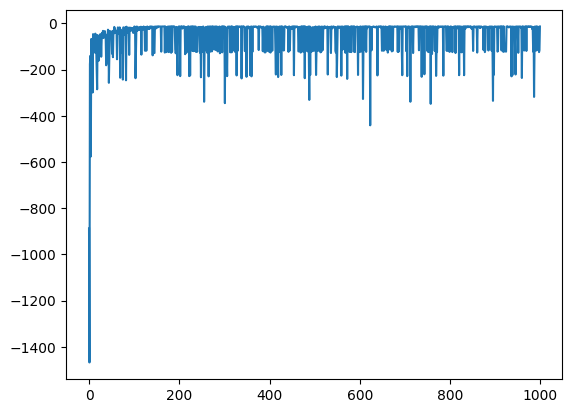

In [48]:
tabela_qlearning = {i: np.array(q) for i, q in tabela_q.items()}
experimentos = 1000
progresso = widgets.IntProgress(min=0, max=experimentos)
display(progresso)
clifwalk=gym.make("CliffWalking-v1")
ator = atorQLearning(tabela_qlearning, 0.1, 1.0, 0.2)
retornos_qlearning = []
for i in range(experimentos):
  ret = simula_clifwalk(clifwalk, ator, 1.0)
  retornos_qlearning.append(ret)
  if i%10==0:
    progresso.value = i
fig, ax = plt.subplots()
ax.plot(retornos_qlearning)
fig.show()


Vejamos o retorno do Q-Learning:

In [49]:
print("Retorno Q-Learning: " + str(simula_clifwalk(clifwalk, atorQGreedy(tabela_qlearning), 1.0)))


Retorno Q-Learning: -13.0


Podemos visualizar a estratégia com uma animação:

In [50]:
imagens = render_tabela(tabela_qlearning)
fig, ax = plt.subplots()
ims = []
for i in range(len(imagens)):
    if i == 0:
        ax.imshow(imagens[0])  # Imagem inicial
        ax.set_title("Estratégia Q-Learning")
    im = ax.imshow(imagens[i], animated=True)
    ims.append([im])
ani = animation.ArtistAnimation(fig, ims, interval=200, blit=True,
                                repeat_delay=1000)
plt.close()
HTML(ani.to_jshtml())


É uma estragégia diferente da do SARSA?
É melhor?

Vamos olhar os retornos *durante* o aprendizado:

C:\Users\mathe\AppData\Local\Temp\ipykernel_24028\2186238601.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


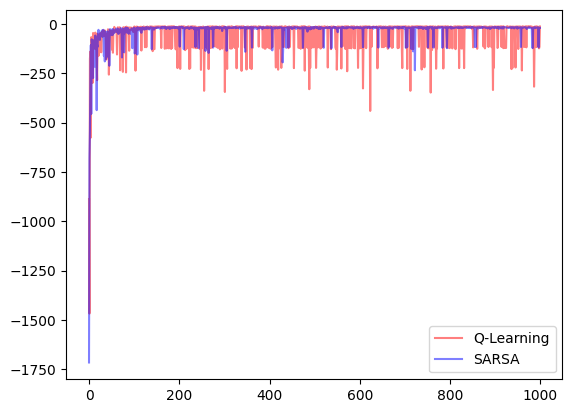

In [52]:
fig, ax = plt.subplots()
ax.plot(retornos_qlearning, alpha=0.5, color='r', label='Q-Learning')
ax.plot(retornos_sarsa, alpha=0.5, color='b', label='SARSA')
ax.legend()
fig.show()


Considerando o exposto, qual dos dois métodos é *on-policy*? Quais dos métodos é *off-policy*?

SARSA é on-policy porque aprende sobre a mesma política que está sendo seguida (epsilon-greedy). A atualização usa Q(S',A') onde A' é a ação realmente escolhida pela política.

Q-Learning é off-policy porque aprende sobre a política ótima (greedy) mesmo quando segue uma política diferente (epsilon-greedy). A atualização usa max Q(S',A'), assumindo sempre a melhor ação possível no próximo estado.

